In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs


In [2]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

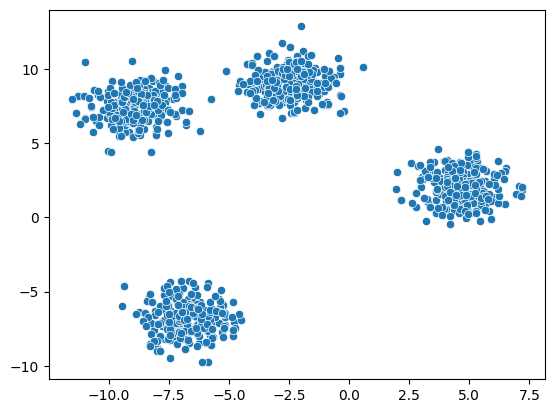

In [5]:
# Visualize
sns.scatterplot(x = X[:, 0], y= X[:, 1])

In [6]:
# K-Means Clustering
from sklearn.cluster import KMeans

In [7]:
K = 4

kmeans = KMeans(
    n_clusters=K,
    random_state=42
)

In [ ]:
labels = kmeans.fit_predict(X)
# label = cluster number

In [9]:
labels

array([3, 1, 1, 2, 2, 1, 2, 1, 1, 2, 2, 3, 0, 1, 1, 1, 0, 0, 0, 2, 2, 3,
       3, 3, 2, 2, 0, 0, 1, 2, 1, 1, 1, 0, 0, 3, 1, 2, 3, 3, 2, 1, 2, 3,
       2, 3, 0, 2, 3, 2, 1, 0, 2, 3, 0, 3, 0, 0, 0, 1, 1, 0, 1, 3, 2, 0,
       1, 1, 2, 0, 3, 0, 2, 1, 2, 3, 2, 0, 2, 0, 1, 0, 0, 0, 2, 3, 1, 1,
       0, 0, 0, 0, 2, 2, 3, 2, 3, 0, 2, 1, 2, 3, 3, 0, 3, 2, 2, 0, 1, 0,
       3, 1, 2, 2, 2, 2, 1, 3, 1, 2, 0, 1, 3, 2, 3, 1, 2, 3, 1, 2, 0, 1,
       2, 3, 2, 3, 0, 1, 2, 2, 0, 0, 3, 3, 3, 2, 2, 0, 0, 0, 0, 3, 1, 1,
       0, 2, 0, 2, 2, 3, 1, 0, 2, 1, 0, 0, 2, 1, 3, 1, 2, 0, 0, 2, 0, 3,
       1, 3, 1, 3, 2, 2, 0, 1, 0, 1, 2, 3, 0, 1, 2, 0, 2, 2, 0, 3, 1, 1,
       1, 3, 0, 1, 2, 0, 2, 2, 1, 0, 2, 1, 1, 3, 1, 1, 2, 0, 1, 0, 3, 2,
       3, 3, 1, 0, 3, 0, 2, 1, 1, 0, 0, 1, 0, 3, 1, 1, 3, 1, 1, 2, 1, 3,
       1, 2, 3, 0, 2, 0, 2, 2, 2, 2, 3, 2, 2, 1, 0, 1, 1, 2, 2, 2, 3, 2,
       3, 3, 1, 2, 0, 3, 2, 0, 2, 1, 0, 3, 2, 3, 1, 2, 3, 1, 3, 2, 1, 0,
       0, 1, 0, 3, 3, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,

<Axes: >

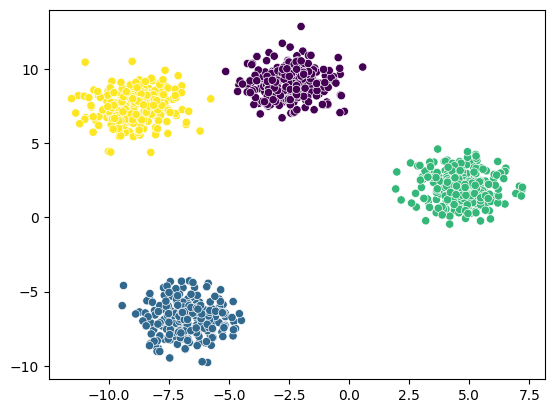

In [11]:
sns.scatterplot (x= X[:, 0], y= X[:, 1], c = labels)

### Choose our K value -  Elbow; Silhoutte Score

In [12]:
# Elbow Method

wcss = []
for k in range(1, 21):
    kmeans= KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

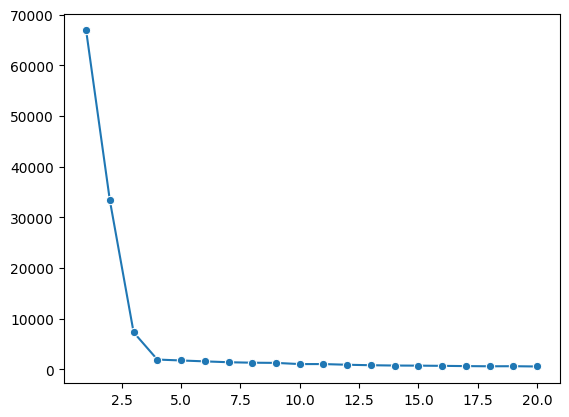

In [15]:
sns.lineplot(x= range(1, 21), y= wcss, marker='o')

In [16]:
# Kneed Module
!pip install kneed


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from kneed import KneeLocator

In [19]:
knee = KneeLocator(range(1,21), wcss, curve="convex", direction="decreasing")

In [22]:
print("optimal k:",knee.knee)

optimal k: 4


## Silhouette Score

In [23]:
from sklearn.metrics import silhouette_score

In [25]:
ss = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    ss.append(score)

<Axes: >

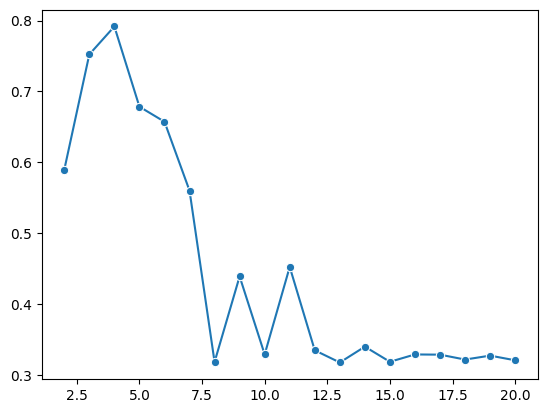

In [28]:
# Plot k and ss

sns.lineplot(x = range(2, 21), y = ss, marker ='o')